# Degeneracy and White Dwarfs

## The Equation of State

Inside of a star, once $T \sim 10^4~\mathrm{K}$, atoms are fully ionized, so we treat ions
and electrons separately.  We also need to consider radiation pressure.  We can write the
total pressure in a star as:

$$P = P_\mathrm{ion} + P_e + P_\gamma$$

```{note}
For stellar atmospheres, we are not in LTE (photons and matter don't have the same temperature), photons
are not trapped, and atoms may be only partially ionized.

We are only worrying about the stellar interior in this lab, so we can neglect these complications.
```

For stellar interiors we can describe these components as:

* ions : these behave as an ideal gas (until we get to neutron stars), so we take:

  $$P_\mathrm{ion} = \frac{\rho k_B T}{\mu_I m_u}$$

  where $\mu_I$ is the mean molecular weight of the ions and $m_u$ is the atomic mass unit.

* radiation : photons are in equilibrium with matter and the mean free path is short compared
  to any scales we care about in the star, so we can treat them as a blackbody:

  $$P_\gamma = \frac{1}{3} a T^4$$

  where $a$ is the radiation constant.

* electrons : these are tricky

  * at low densities / high temperatures, electrons behave as an ideal gas
  * at high densities / low temperatures, quantum mechanical effects become important.
    Because we are confining the electrons to a small volume, the Pauli exclusion principle
    comes into play, and says that the electrons need to take on high momentum.  This
    gives rise to a quantum mechanical pressure we call *degeneracy pressure*.

```{note}
We usually include an additional contribution, *Coulomb corrections*, to the pressure.
This accounts for the non-ideal nature of the ions (due to their electric charge) at high densities,
and lowers the pressure.
```

## Fermi-Dirac statistics

We describe the statistics of particles through a distribution function:

$$n(p) d^3 x d^3 p = \mbox{\# of particles with momentum $p$ to $p + dp$ in a volume $d^3x$}$$

For electrons, the distribution function is the [Fermi-Dirac distribution](https://en.wikipedia.org/wiki/Fermi%E2%80%93Dirac_statistics).


$$n(p) = \frac{2}{h^3} \frac{1}{e^{\mathcal{E}(p)/{k_B T} - \eta} + 1}$$

where $\mathcal{E}$ is the kinetic energy of the electron, $T$ is the temperature, and $\eta$ is the _degeneracy parameter_ which is related to the [chemical potential](https://en.wikipedia.org/wiki/Chemical_potential), $\mu$, via:

$$\eta = \frac{\mu - m_e c^2}{k_B T}$$


```{note}
At low density and high-temperature, electron-positron pairs can be produced,
and we would need to consider the positron contribution to the EOS.  For the
conditions we will be looking at in the white dwarf interior, these will not
be important.
```

### Thermodynamic quantities

To get the _number density_, we integrate over all momenta:

$$n = \int n(p) d^3 p$$

The pressure and specific internal energy, $e$, are then found as:

$$P = \frac{1}{3} \int n(p) v(p) p d^3 p$$
$$\rho e = \int n(p) \mathcal{E}(p) d^3 p$$

### Fermi energy

We define [Fermi energy](https://en.wikipedia.org/wiki/Fermi_energy), $\mathcal{E}_F$, as:
 
$$\mathcal{E}_F = \mu - m_e c^2$$

and then

$$\eta = \frac{\mu - m_e c^2}{k_B T} = \frac{\mathcal{E}_F}{k_B T}$$

## Degeneracy

We can understand the behavior of the electrons in terms of $\eta$:

* $-\eta \gg 1$ : the electrons behave as an ideal gas.  In this case, the $+1$ in the denominator of $n(p)$ is insignificant and we get the Maxwell-Boltzmann distribution.

* $\eta \gg 1$ : the electrons are degenerate (Fermi energy is much greater than the thermal energy).


## Transition to degeneracy

Let's look at the behavior of the distribution function.  Consider:

$$F(\mathcal{E}) = \frac{1}{e^{\mathcal{E}/k_B T - \eta} + 1}$$

let's define

$$\xi \equiv \frac{\mathcal{E}}{k_B T}$$

then we have

$$F(\xi) = \frac{1}{e^{\xi - \eta} + 1}$$

and for each choice of $\eta$ we have a unique distribution.

We note that $\xi/\eta = \mathcal{E}/\mathcal{E}_F$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def F(xi, eta=100):
    return 1.0 / (np.exp(xi - eta) + 1)

Let's look at the case of $\eta > 1$

Text(0.5, 0, '$\\mathcal{E}/\\mathcal{E}_F$')

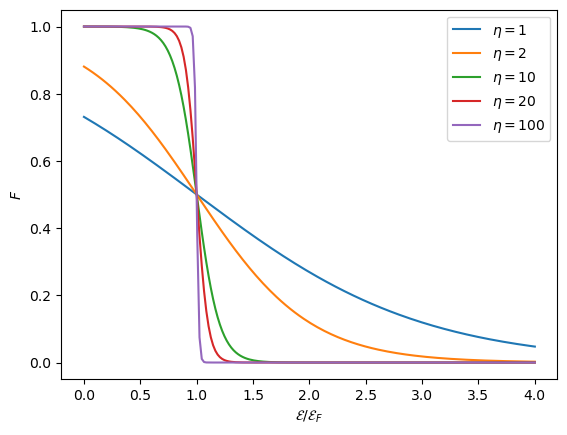

In [5]:
fig, ax = plt.subplots()

# we'll work in terms of r = xi / eta
r = np.linspace(0, 4, 200)

for eta in [1, 2, 10, 20, 100]:
    ax.plot(r, F(eta * r, eta=eta), label=fr"$\eta = {eta}$")
    
ax.legend()
ax.set_ylabel("$F$")
ax.set_xlabel(r"$\mathcal{E}/\mathcal{E}_F$")

In the limit that $T \rightarrow 0$ (complete degeneracy), then we have:

$$F(\mathcal{E}) = \left \{ \begin{array}{cc} 1 & \mathcal{E} < \mathcal{E}_F \\
                                              0 & \mathcal{E} > \mathcal{E}_F \end{array} \right .$$

So the distrbution function tends to a step-function when we are really degenerate *and*
the most energetic electrons have a kinetic energy = Fermi energy.

```{note}
Conceptually:

* At $T = 0$, the Fermi energy is the energy of the highest occupied state in the distribution function.

* Since electrons have a non-zero energy / momentum, even at $T = 0$, there will be a pressure
  even in the limit $T \rightarrow 0$!

* Even for non-zero $T$, as long as $\eta \gg 1$, we can still think of $\mathcal{E}_F$ as being (roughly) the energy of the most energetic
  electrons.

* We can think of $\eta$ as (roughly) the ratio of the Fermi energy to the thermal energy
```

### Fermi momentum

We can alternately use the Fermi momentum, $p_F$ to describe the location of the step.  Two important limits are:

$$\mathcal{E}_F = \begin{cases} \frac{p_F^2}{2 m_e} & \mbox{non-relativisitic} \\
                                p_F c & \mbox{extremely relativisitic} \end{cases}$$

### Zero-T limit

For $T \rightarrow 0$, the integral for number density is trivial:

$$n_e = \frac{2}{h^3} \int_0^{p_F} d^3p = \frac{8\pi}{h^3} \int_0^{p_F} p^2 dp$$

where we switched to spherical coordinates in momentum space: $d^3p \rightarrow 4\pi p^2 dp$.

Performing this integral, we get the Fermi momentum in terms of the number density of electrons:

$$n_e = \frac{8\pi}{3h^3} p_F^3 \rightarrow p_F = \left (\frac{3}{8\pi} \right)^{1/3} h n_e^{1/3}$$

## Computing $\eta$

For other values of $\eta$, we have a problem:

$$n_e = \frac{8\pi}{h^3} \int_0^\infty \frac{p^2}{e^{\mathcal{E}(p)/k_B T - \eta} + 1} dp$$

We don't know what the value of $\eta$ is ahead of time.  Instead, we typically know what the density of the star is, and we can find the
number density of electrons as:

$$n_e = \frac{\rho Y_e}{m_u}$$

where $Y_e$ is the electron fraction (typically around $1/2$ for compositions heavier than hydrogen).  This means that given $\rho, T$,
we can solve for $\eta$.


The kinetic energy of a particle can be found from the relativisitic expression:

$$\mathcal{E}(p) = m_e c^2 \left [ \sqrt{1 + \left ( \frac{p}{m_e c} \right )^2 } - 1 \right ]$$

```{note}
This has the proper limit in the non-relativistic case, $|p| \ll m_e c$:

$$\mathcal{E} = \frac{p^2}{2m_e}$$

Once we have $\eta$, we can then find the pressure and energy of the gas.

```{tip}
We normally express these integrals in terms of energy.  These integrals can be computed
via pynucastro (see https://pynucastro.github.io/pynucastro/fermi-integrals.html)

A C++ code that computes these at very high precision is available at https://github.com/zingale/electron_positron_cxx
```

## Finding the trend of $\eta$ with $\rho, T$


In [6]:
import pynucastro as pyna

In [7]:
eos = pyna.eos.ElectronEOS()

In [8]:
import numpy as np

In [9]:
comp = pyna.Composition(["o16", "ne20"])
comp.set_equal()

We'll store $\eta$ and $P$ for a range of densities at a few different temperatures.

In [25]:
rhos = np.logspace(0, 9, 100)

etas = {}
ps = {}
for T in [1.e6, 1.e7, 1.e8]:
    etas[T] = []
    ps[T] = []
    for rho in rhos:
        # by default, this gives both the electron and
        # positron contributions.  We'll ignore the positrons
        ee, _ = eos.pe_state(rho, T, comp)
        etas[T].append(ee.eta)
        ps[T].append(ee.p)

Let's visualize $\eta$

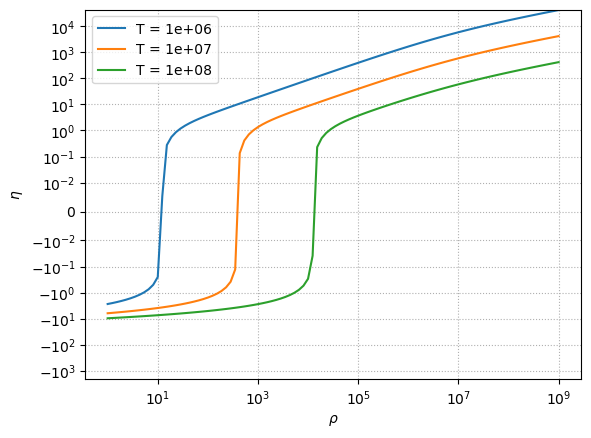

In [26]:
fig, ax = plt.subplots()

for T in etas:
    ax.plot(rhos, etas[T], label=f"T = {T:5.2g}")

ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$\eta$")
ax.set_xscale("log")
ax.set_yscale("symlog", linthresh=1.e-2)
ax.legend()
ax.grid(ls=":")

## Pressure at zero-T

At zero-temperature, the distribution function is a step function, and then integrals become straightforward.

The number density is just:

$$n_e = \frac{8\pi}{h^3} \int_0^{\mathcal{p}_F} p^2 dp = \frac{8\pi}{3 h^3} p_F^3$$

or, the Fermi momentum is:

$$p_F = \left (\frac{3 h^3}{8\pi} \right )^{1/3} n_e^{1/3}$$


For the pressure, we need $v(p)$, which from mechanics is:

$$v(p) = \frac{p}{m_e} \left [ 1 + \left (\frac{p}{m_e c} \right )^2 \right ]^{-1/2}$$

and taking $T \rightarrow 0$, our pressure integral becomes:

$$P = \frac{8\pi}{3 h^3} \int_0^{p_F} p v(p) p^2 dp$$

Performing this integral, we find:

$$P(x) = \frac{\pi}{3} \left (\frac{m_e c}{h} \right )^3 m_e c^2 \left [ x (2x^2 - 3) (1 + x^2)^{1/2} + 3 \sinh^{-1}x \right ]$$

where $x$ is the dimensionless Fermi energy:

$$x = \left (\frac{3}{8\pi} \right )^{1/3} \frac{h}{m_e c} n_e^{1/3}$$

## Exploring the transition to degeneracy

We can compare the exact expression to this zero-T expression to see when
the transition to degeneracy occurs.

In [18]:
m_u = pyna.constants.constants.m_u
h_planck = pyna.constants.constants.h
c = pyna.constants.constants.c_light
m_e = pyna.constants.constants.m_e

In [24]:
def p_zero_temp(rho, Ye=0.5):
    
    # find number density
    n_e = rho * Ye / m_u
    
    # find Fermi momentum
    x_F = (3 / (8 * np.pi))**(1/3) * (h_planck / (m_e * c)) * n_e**(1/3)
    
    P = (np.pi/3) * (m_e * c / h_planck)**3 * m_e * c**2 * (x_F * (2*x_F**2 - 3) *
                                                            np.sqrt(1 + x_F**2) + 3 *
                                                            np.arcsinh(x_F))
    return P

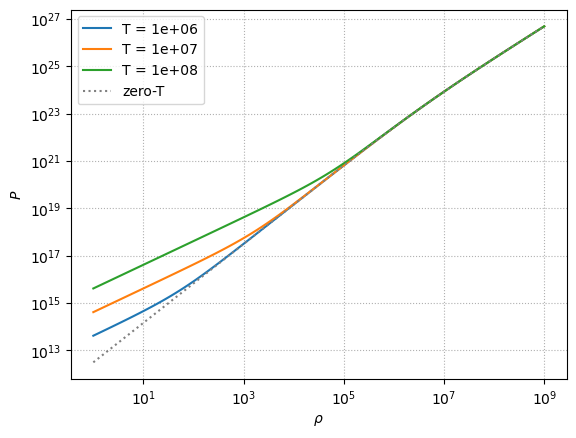

In [33]:
fig, ax = plt.subplots()

for T in ps:
    ax.loglog(rhos, ps[T], label=f"T = {T:5.2g}")

ax.loglog(rhos, p_zero_temp(rhos), linestyle=":", color="0.5", label="zero-T")

ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$P$")
ax.grid(ls=":")
ax.legend()

We see that at high density, the pressure matches the zero-T approximation well.
At lower densities, the electrons break from the zero-T curve and act as an
ideal gas.